<a href="https://colab.research.google.com/github/Sangeetha231005/MLops-training/blob/main/Task8_Smart_Factory_Machinery_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1 - Linear Regression**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Smart Factory Machinery Predictor/ai4i2020.csv')
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear   
0                    1551         42.8           0  
1                    1408         46.3           3  
2                    1498         49.4           5  
3                    1433         39.5           7  
4                    1408         40.0           9  


In [ ]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear '],
      dtype='object')


In [ ]:
X = df[["Rotational speed [rpm]"]]

In [ ]:
y = df["Process temperature [K]"]

In [ ]:
print(X.shape)
print(y.shape)

(10000, 1)
(10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [0.00018222]
Intercept: 309.72569391219616


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

[310.00594598 309.98462642 309.9962884  310.01578578 310.06553144
 309.98025317 309.98808857 309.96895563 310.02052347 310.00539933]


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 2.1691240317336407


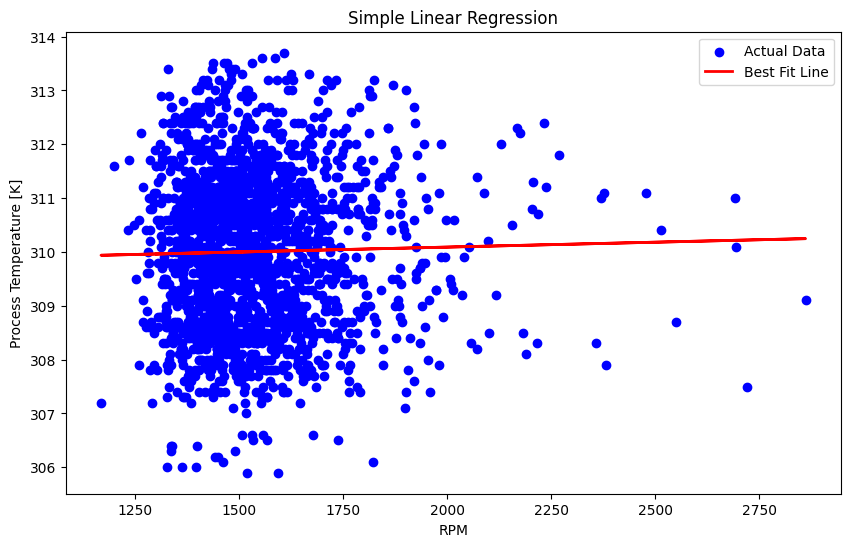

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(
    X_test,
    y_test,
    color="blue",
    label="Actual Data"
)
plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=2,
    label="Best Fit Line"
)
plt.xlabel("RPM")
plt.ylabel("Process Temperature [K]")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

**Task 2 - Multivariate Linear Regression**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Smart Factory Machinery Predictor/ai4i2020.csv')
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear   
0                    1551         42.8           0  
1                    1408         46.3           3  
2                    1498         49.4           5  
3                    1433         39.5           7  
4                    1408         40.0           9  


In [ ]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear '],
      dtype='object')


In [ ]:
X = df[[
    "Air temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear "
]]

In [ ]:
y = df["Process temperature [K]"]

In [ ]:
print(X.shape)
print(y.shape)

(10000, 4)
(10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 6.51688239e-01 -9.91872755e-05 -2.44969676e-03 -6.58579419e-05]
Intercept: 114.75089892348998


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

[310.52469735 312.34610519 308.89161496 312.16655897 311.5693948
 310.31837897 308.47789972 312.40041956 310.00471621 308.32261057]


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.529870876536166


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.5950203593981018


In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7556839897973872


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual   Predicted
0   310.3  310.524697
1   311.8  312.346105
2   307.9  308.891615
3   311.3  312.166559
4   310.4  311.569395
5   309.9  310.318379
6   309.7  308.477900
7   312.7  312.400420
8   309.6  310.004716
9   308.3  308.322611


**Task 3  - Save and Load the Model using Joblib**

In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Smart Factory Machinery Predictor/ai4i2020.csv')
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear   
0                    1551         42.8           0  
1                    1408         46.3           3  
2                    1498         49.4           5  
3                    1433         39.5           7  
4                    1408         40.0           9  


In [ ]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear '],
      dtype='object')


In [ ]:
X = df[[
    "Air temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear "
]]

In [ ]:
y = df["Process temperature [K]"]

In [ ]:
print(X.shape)
print(y.shape)

(10000, 4)
(10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 6.51688239e-01 -9.91872755e-05 -2.44969676e-03 -6.58579419e-05]
Intercept: 114.75089892348998


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

[310.52469735 312.34610519 308.89161496 312.16655897 311.5693948
 310.31837897 308.47789972 312.40041956 310.00471621 308.32261057]


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.529870876536166


In [ ]:
joblib.dump(model, "temperature_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
model = joblib.load("temperature_model.pkl")

In [ ]:
new_machine = pd.DataFrame({
    "Air temperature [K]": [298.5],
    "Rotational speed [rpm]": [1600],
    "Torque [Nm]": [40],
    "Tool wear ": [120]
})

In [ ]:
predicted_temperature = model.predict(new_machine)

In [ ]:
print("\nPredicted Process Temperature:")
print(predicted_temperature[0])


Predicted Process Temperature:
309.0152478955489


**Task 4 - OneHot Encoding**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Smart Factory Machinery Predictor/ai4i2020.csv')

In [ ]:
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear   
0                    1551         42.8           0  
1                    1408         46.3           3  
2                    1498         49.4           5  
3                    1433         39.5           7  
4                    1408         40.0           9  


In [ ]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear '],
      dtype='object')


In [ ]:
print(df["Type"].head(10))

0    M
1    L
2    L
3    L
4    L
5    M
6    L
7    L
8    M
9    M
Name: Type, dtype: object


In [ ]:
encoded_df = pd.get_dummies(
    df,
    columns=["Type"]
)

In [ ]:
print(encoded_df.head())

   UDI Product ID  Air temperature [K]  Process temperature [K]  \
0    1     M14860                298.1                    308.6   
1    2     L47181                298.2                    308.7   
2    3     L47182                298.1                    308.5   
3    4     L47183                298.2                    308.6   
4    5     L47184                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear   Type_H  Type_L  Type_M  
0                    1551         42.8           0   False   False    True  
1                    1408         46.3           3   False    True   False  
2                    1498         49.4           5   False    True   False  
3                    1433         39.5           7   False    True   False  
4                    1408         40.0           9   False    True   False  


In [ ]:
encoded_df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

In [ ]:
print(encoded_df.head())

   UDI Product ID  Air temperature [K]  Process temperature [K]  \
0    1     M14860                298.1                    308.6   
1    2     L47181                298.2                    308.7   
2    3     L47182                298.1                    308.5   
3    4     L47183                298.2                    308.6   
4    5     L47184                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear   Type_L  Type_M  
0                    1551         42.8           0   False    True  
1                    1408         46.3           3    True   False  
2                    1498         49.4           5    True   False  
3                    1433         39.5           7    True   False  
4                    1408         40.0           9    True   False  


**Task 5  - Test and Train Split**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Smart Factory Machinery Predictor/ai4i2020.csv')
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear   
0                    1551         42.8           0  
1                    1408         46.3           3  
2                    1498         49.4           5  
3                    1433         39.5           7  
4                    1408         40.0           9  


In [ ]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear '],
      dtype='object')


In [ ]:
X = df[["Rotational speed [rpm]"]]

In [ ]:
y = df["Process temperature [K]"]

In [ ]:
print(X.shape)
print(y.shape)

(10000, 1)
(10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [0.00018222]
Intercept: 309.72569391219616


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

[310.00594598 309.98462642 309.9962884  310.01578578 310.06553144
 309.98025317 309.98808857 309.96895563 310.02052347 310.00539933]


**Task 6 - Logistic Regression**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Smart Factory Machinery Predictor/ai4i2020.csv')

In [ ]:
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear   
0                    1551         42.8           0  
1                    1408         46.3           3  
2                    1498         49.4           5  
3                    1433         39.5           7  
4                    1408         40.0           9  


In [ ]:
df["Defective"] = (
    (df["Air temperature [K]"] > 303) |
    (df["Process temperature [K]"] > 312) |
    (df["Rotational speed [rpm]"] > 2500) |
    (df["Torque [Nm]"] > 60) |
    (df["Tool wear "] > 200)
).astype(int)

In [ ]:
print(df["Defective"].value_counts())

Defective
0    8067
1    1933
Name: count, dtype: int64


In [ ]:
encoded_df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

In [ ]:
print(encoded_df.head())

   UDI Product ID  Air temperature [K]  Process temperature [K]  \
0    1     M14860                298.1                    308.6   
1    2     L47181                298.2                    308.7   
2    3     L47182                298.1                    308.5   
3    4     L47183                298.2                    308.6   
4    5     L47184                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear   Defective  Type_L  Type_M  
0                    1551         42.8           0          0   False    True  
1                    1408         46.3           3          0    True   False  
2                    1498         49.4           5          0    True   False  
3                    1433         39.5           7          0    True   False  
4                    1408         40.0           9          0    True   False  


In [ ]:
X = encoded_df[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear ",
    "Type_L",
    "Type_M"
]]

In [ ]:
y = encoded_df["Defective"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:20])

[0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8585
